# Experiment 5 — Experiment 3, but with Reddit sentiment instead of news

Same design as experiment 3 (correlate sentiment(t) vs TSLA forward cumulative return
across horizons), with **one change: the sentiment source is Reddit (r/teslamotors)
posts** instead of CNBC news.

**Question:** Which forward horizon (if any) correlates with *retail* Reddit sentiment,
and does it behave differently from the professional news sentiment of exp 1–4?

**Data:** `data/tsla-reddit-2024/` posts — 21,135 posts, 2024-01-01 → 2026-07-22 (full
window). Comments excluded (only cover Jan–May 2024). Scored with **FinBERT + VADER**,
mirroring exp 3.

In [1]:
# 1. Setup
import html
import re
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "experiment_5" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
POSTS = REPO_ROOT / "data" / "tsla-reddit-2024" / "r_teslamotors_posts.jsonl"

vader = SentimentIntensityAnalyzer()
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).eval()
device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)
lbl = {v.lower(): k for k, v in model.config.id2label.items()}
POS, NEG = lbl["positive"], lbl["negative"]
print("Device:", device)

/Users/georgia/Documents/Trading/sentimental_trading/trade_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 34253.82it/s]

Device: mps


## 2. Parse the Reddit posts

In [2]:
# 2. Load posts JSONL -> [date, title, selftext]
import json
recs = []
with open(POSTS) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            d = json.loads(line)
        except json.JSONDecodeError:
            continue
        c = d.get("created_utc")
        if c is None:
            continue
        recs.append({"date": datetime.fromtimestamp(float(c), timezone.utc).date(),
                     "title": d.get("title", "") or "",
                     "selftext": d.get("selftext", "") or ""})
posts = pd.DataFrame(recs)
posts["date"] = pd.to_datetime(posts["date"])
print(f"{len(posts):,} posts, {posts['date'].min().date()} -> {posts['date'].max().date()}")
posts.head(3)

21,135 posts, 2024-01-01 -> 2026-07-22


,date,title,selftext
0,2024-01-01,Cybertruck single motor pre order,[removed]
1,2024-01-01,Mobile Charger Damaged,[removed]
2,2024-01-01,Buying used Tesla from Tesla,[removed]


## 3. Clean text
Unescape HTML, strip URLs/markdown. `[removed]`/`[deleted]`/empty selftext → treated as no body (title-only post).

In [3]:
# 3. Reddit text cleaning
URL = re.compile(r"http\S+|www\.\S+")
def clean(text):
    if not isinstance(text, str):
        return ""
    t = text.strip()
    if t.lower() in ("[removed]", "[deleted]", ""):
        return ""
    t = html.unescape(t)
    t = re.sub(r"!\[[^\]]*\]\([^)]*\)", " ", t)      # md images
    t = re.sub(r"\[([^\]]*)\]\([^)]*\)", r"\1", t)     # md links -> text
    t = URL.sub(" ", t)
    t = re.sub(r"[>#*_`~]+", " ", t)                     # md symbols
    t = re.sub(r"\s+", " ", t).strip()
    return t

posts["title_clean"] = posts["title"].apply(lambda t: html.unescape(t).strip())
posts["body_clean"] = posts["selftext"].apply(clean)
print("posts with non-empty body:", int((posts["body_clean"] != "").sum()),
      f"({(posts['body_clean'] != '').mean():.0%})")
posts[["date", "title_clean", "body_clean"]].head(3)

posts with non-empty body: 732 (3%)


,date,title_clean,body_clean
0,2024-01-01,Cybertruck single motor pre order,
1,2024-01-01,Mobile Charger Damaged,
2,2024-01-01,Buying used Tesla from Tesla,


## 4. Score with FinBERT + VADER
Per post: headline score + body score (only if body present), averaged. Same structure as exp 1/2.

In [4]:
# 4a. FinBERT (batched) — signed score p(pos)-p(neg)
@torch.no_grad()
def finbert_scores(texts, batch_size=32, max_length=512):
    out = []
    n = len(texts)
    for i in range(0, n, batch_size):
        batch = [t if isinstance(t, str) and t.strip() else "neutral" for t in texts[i:i + batch_size]]
        enc = tokenizer(batch, return_tensors="pt", truncation=True,
                        max_length=max_length, padding=True).to(device)
        probs = torch.softmax(model(**enc).logits, dim=-1)
        out.extend((probs[:, POS] - probs[:, NEG]).cpu().numpy().tolist())
        if (i // batch_size) % 40 == 0:
            print(f"  {min(i + batch_size, n):,}/{n:,}", end="\r")
    return out

def scatter_body(values, idx, n):
    arr = np.full(n, np.nan)
    for j, i in enumerate(idx):
        arr[i] = values[j]
    return arr

bodies = posts["body_clean"].tolist()
body_idx = [i for i, b in enumerate(bodies) if b]

print("FinBERT titles...")
posts["hl_finbert"] = finbert_scores(posts["title_clean"].tolist())
print("\nFinBERT bodies...")
posts["body_finbert"] = scatter_body(finbert_scores([bodies[i] for i in body_idx]), body_idx, len(bodies))
posts["post_finbert"] = posts[["hl_finbert", "body_finbert"]].mean(axis=1)  # skips NaN body
print("\nFinBERT done.")

FinBERT titles...



FinBERT bodies...



FinBERT done.


In [5]:
# 4b. VADER — headline compound + body sentence-average
SENT = re.compile(r"(?<=[.!?])\s+")
def vader_body(text):
    sents = [s for s in SENT.split(text) if s.strip()]
    if not sents:
        return np.nan
    return float(np.mean([vader.polarity_scores(s)["compound"] for s in sents]))

posts["hl_vader"] = posts["title_clean"].apply(lambda t: vader.polarity_scores(t)["compound"])
posts["body_vader"] = posts["body_clean"].apply(lambda b: vader_body(b) if b else np.nan)
posts["post_vader"] = posts[["hl_vader", "body_vader"]].mean(axis=1)
print("FinBERT range:", round(posts["post_finbert"].min(), 3), "to", round(posts["post_finbert"].max(), 3))
print("VADER   range:", round(posts["post_vader"].min(), 3), "to", round(posts["post_vader"].max(), 3))
posts[["date", "title_clean", "post_finbert", "post_vader"]].head()

FinBERT range: -0.969 to 0.942
VADER   range: -0.966 to 0.991


,date,title_clean,post_finbert,post_vader
0,2024-01-01,Cybertruck single motor pre order,-0.025700,0.0000
1,2024-01-01,Mobile Charger Damaged,-0.000811,-0.4404
2,2024-01-01,Buying used Tesla from Tesla,0.084752,0.0000
3,2024-01-01,The new parking assist is working well!,0.845481,0.3382
4,2024-01-01,Tesla referral code £250 off plus additional p...,0.033638,0.0000


## 5. Aggregate to daily sentiment

In [6]:
# 5. Daily mean + post count
daily = (posts.groupby("date")
         .agg(finbert=("post_finbert", "mean"), vader=("post_vader", "mean"),
              count=("post_finbert", "size")).reset_index())
print(f"{len(daily)} calendar days with >=1 post")
daily.describe().round(3)

934 calendar days with >=1 post


,date,finbert,vader,count
count,934,934.000,934.000,934.000
mean,2025-04-11 12:00:00,-0.032,0.033,22.628
min,2024-01-01 00:00:00,-0.328,-0.238,1.000
25%,2024-08-21 06:00:00,-0.080,-0.011,13.000
50%,2025-04-11 12:00:00,-0.028,0.028,19.000
75%,2025-11-30 18:00:00,0.018,0.080,30.000
max,2026-07-22 00:00:00,0.273,0.625,87.000
std,NaN,0.082,0.080,12.976


## 6. Prices & forward returns (identical to exp 3)

In [7]:
# 6. Daily bars + forward cumulative returns
import get_bars as gb
end = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
def fetch(feed):
    return list(gb.get_bars({"timeframe": "1Day", "start": "2024-01-01T00:00:00Z",
                             "end": end, "limit": 10000, "adjustment": "split",
                             "feed": feed, "sort": "asc"}))
try:
    bars = fetch("sip"); feed_used = "sip"
except Exception:
    print("SIP failed -> IEX"); bars = fetch("iex"); feed_used = "iex"

prices = pd.DataFrame(bars)
prices["date"] = pd.to_datetime(prices["t"], utc=True).dt.tz_localize(None).dt.normalize()
prices = prices.sort_values("date").reset_index(drop=True)
HORIZONS = [("+1d", 1), ("+3d", 3), ("1 week (5d)", 5), ("2 weeks (10d)", 10),
            ("3 weeks (15d)", 15), ("1 month (21d)", 21), ("2 months (42d)", 42),
            ("3 months (63d)", 63)]
for _, h in HORIZONS:
    prices[f"fwd_{h}"] = prices["c"].shift(-h) / prices["c"] - 1.0
prices["same_day"] = prices["c"].pct_change()
print(f"{len(prices)} bars via {feed_used}: {prices['date'].min().date()} -> {prices['date'].max().date()}")

SIP failed -> IEX


639 bars via iex: 2024-01-02 -> 2026-07-21


## 7. Align to trading days & merge

In [8]:
# 7. Next-trading-day alignment (post-count-weighted), then merge
trading_days = prices["date"].to_numpy()
def next_td(d):
    idx = np.searchsorted(trading_days, np.datetime64(d), side="left")
    return pd.Timestamp(trading_days[idx]) if idx < len(trading_days) else pd.NaT
daily["td"] = daily["date"].apply(next_td)
tmp = daily.dropna(subset=["td"]).copy()
for col in ["finbert", "vader"]:
    tmp[f"w_{col}"] = tmp[col] * tmp["count"]
agg = (tmp.groupby("td")
       .agg(w_finbert=("w_finbert", "sum"), w_vader=("w_vader", "sum"),
            count=("count", "sum")).reset_index())
agg["finbert_sentiment"] = agg["w_finbert"] / agg["count"]
agg["vader_sentiment"] = agg["w_vader"] / agg["count"]
agg = agg.rename(columns={"td": "date"})[["date", "finbert_sentiment", "vader_sentiment", "count"]]

df = prices.merge(agg, on="date", how="inner").sort_values("date").reset_index(drop=True)
df.to_csv("tsla_reddit_daily.csv", index=False)
print(f"{len(df)} trading days with Reddit sentiment | non-NaN fwd_63: {int(df['fwd_63'].notna().sum())}")
df[["date", "c", "count", "finbert_sentiment", "vader_sentiment", "fwd_5", "fwd_21"]].head()

639 trading days with Reddit sentiment | non-NaN fwd_63: 576


,date,c,count,finbert_sentiment,vader_sentiment,fwd_5,fwd_21
0,2024-01-02,248.48,104,0.000421,0.003521,-0.054733,-0.240140
1,2024-01-03,238.44,66,0.032045,0.078982,-0.019082,-0.212255
2,2024-01-04,237.94,59,-0.037606,0.072503,-0.045011,-0.239094
3,2024-01-05,237.48,68,-0.050365,0.060061,-0.078533,-0.220692
4,2024-01-08,240.42,165,-0.046067,-0.017668,-0.085059,-0.219657


## 8. Correlation vs horizon (Reddit)

In [9]:
# 8. Correlations
def corr(x, y):
    m = x.notna() & y.notna()
    if m.sum() < 10:
        return int(m.sum()), np.nan, np.nan, np.nan, np.nan
    pr, pp = stats.pearsonr(x[m], y[m])
    sr, sp = stats.spearmanr(x[m], y[m])
    return int(m.sum()), pr, pp, sr, sp

rows = []
for model_name, col in [("FinBERT", "finbert_sentiment"), ("VADER", "vader_sentiment")]:
    n, pr, pp, sr, sp = corr(df[col], df["same_day"])
    rows.append({"model": model_name, "horizon": "same-day (0d)", "days": 0, "n": n,
                 "pearson_r": pr, "pearson_p": pp, "spearman_r": sr, "spearman_p": sp})
    for label, h in HORIZONS:
        n, pr, pp, sr, sp = corr(df[col], df[f"fwd_{h}"])
        rows.append({"model": model_name, "horizon": label, "days": h, "n": n,
                     "pearson_r": pr, "pearson_p": pp, "spearman_r": sr, "spearman_p": sp})
table = pd.DataFrame(rows)
table.to_csv("tsla_reddit_horizon_correlations.csv", index=False)
table.round(4)

,model,horizon,days,n,pearson_r,pearson_p,spearman_r,spearman_p
0,FinBERT,same-day (0d),0,638,0.0235,0.5541,0.0186,0.6383
1,FinBERT,+1d,1,638,0.0710,0.0732,0.0486,0.2205
2,FinBERT,+3d,3,636,0.0381,0.3380,0.0271,0.4958
3,FinBERT,1 week (5d),5,634,0.0015,0.9702,0.0115,0.7724
4,FinBERT,2 weeks (10d),10,629,-0.0651,0.1027,-0.0797,0.0458
5,FinBERT,3 weeks (15d),15,624,-0.0011,0.9786,-0.0335,0.4038
6,FinBERT,1 month (21d),21,618,0.0164,0.6843,-0.0115,0.7751
7,FinBERT,2 months (42d),42,597,-0.0276,0.5006,-0.0685,0.0947
8,FinBERT,3 months (63d),63,576,-0.0769,0.0652,-0.1001,0.0163
9,VADER,same-day (0d),0,638,-0.0577,0.1453,-0.0239,0.5475


## 9. Plots

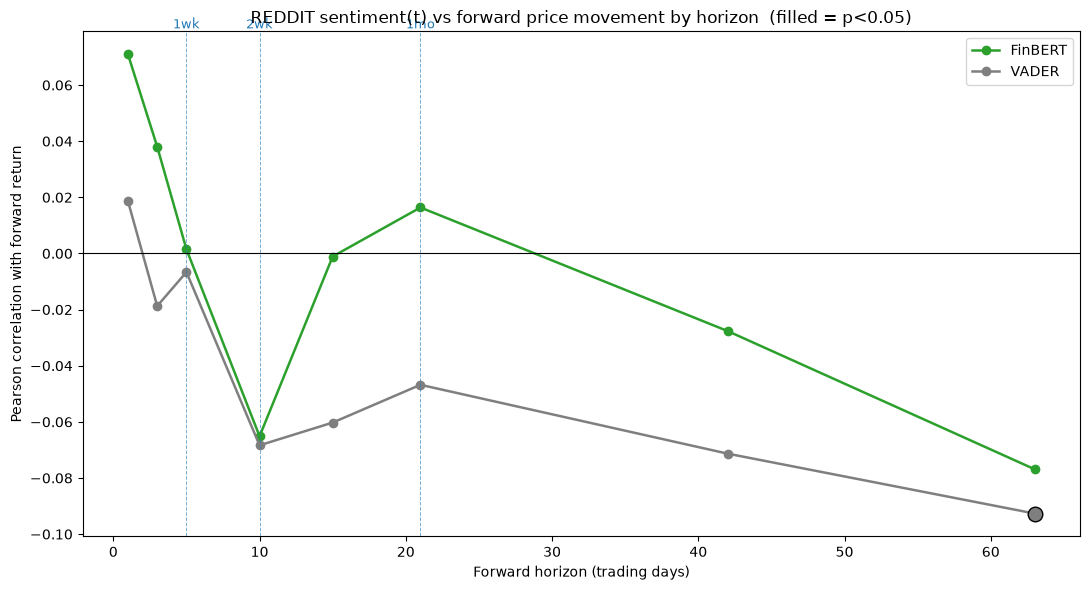

In [10]:
# 9a. Correlation vs horizon (Reddit) — FinBERT & VADER
fig, ax = plt.subplots(figsize=(11, 6))
for model_name, color in [("FinBERT", "tab:green"), ("VADER", "tab:gray")]:
    sub = table[(table["model"] == model_name) & (table["days"] > 0)].sort_values("days")
    ax.plot(sub["days"], sub["pearson_r"], "-o", color=color, lw=1.8, label=model_name)
    sig = sub[sub["pearson_p"] < 0.05]
    ax.scatter(sig["days"], sig["pearson_r"], s=110, facecolors=color, edgecolors="black", zorder=5)
ax.axhline(0, color="black", lw=0.8)
for d, lab in [(5, "1wk"), (10, "2wk"), (21, "1mo")]:
    ax.axvline(d, color="tab:blue", ls="--", lw=0.7, alpha=0.6)
    ax.text(d, ax.get_ylim()[1], lab, color="tab:blue", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Forward horizon (trading days)")
ax.set_ylabel("Pearson correlation with forward return")
ax.set_title("REDDIT sentiment(t) vs forward price movement by horizon  (filled = p<0.05)")
ax.legend(); plt.tight_layout(); plt.show()

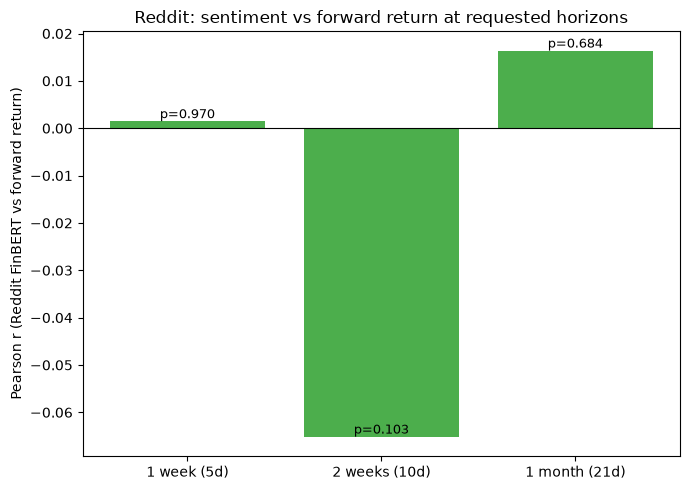

In [11]:
# 9b. Requested horizons, FinBERT (Reddit)
req = table[(table["model"] == "FinBERT") & (table["horizon"].isin(
    ["1 week (5d)", "2 weeks (10d)", "1 month (21d)"]))]
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(req["horizon"], req["pearson_r"], color="tab:green", alpha=0.85)
for b, p in zip(bars, req["pearson_p"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"p={p:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Pearson r (Reddit FinBERT vs forward return)")
ax.set_title("Reddit: sentiment vs forward return at requested horizons")
plt.tight_layout(); plt.show()

## 10. Verdict + comparison to experiment 3 (news)

In [12]:
# 10. Strongest horizon + side-by-side vs exp 3 news numbers
fb = table[(table["model"] == "FinBERT") & (table["days"] > 0)].copy()
fb["abs_r"] = fb["pearson_r"].abs()
best = fb.loc[fb["abs_r"].idxmax()]
sd = table[(table["model"] == "FinBERT") & (table["horizon"] == "same-day (0d)")].iloc[0]

print("QUESTION: which forward horizon correlates with REDDIT sentiment(t)?")
print("=" * 74)
print(f"{'horizon':<18}{'Pearson r':>12}{'p-value':>12}{'sig?':>8}")
print("-" * 74)
for _, r in fb.sort_values("days").iterrows():
    print(f"{r['horizon']:<18}{r['pearson_r']:>+12.3f}{r['pearson_p']:>12.4f}{('yes' if r['pearson_p']<0.05 else 'no'):>8}")
print("-" * 74)
print(f"same-day (reference)      {sd['pearson_r']:>+7.3f}   p={sd['pearson_p']:.4f}")

print("\n" + "=" * 74)
print(f"STRONGEST forward horizon (Reddit/FinBERT): {best['horizon']} "
      f"(r={best['pearson_r']:+.3f}, p={best['pearson_p']:.4f})")

# Try to load experiment 3's news numbers for direct comparison
try:
    news = pd.read_csv(REPO_ROOT / "experiment_3" / "tsla_horizon_correlations.csv")
    news_fb = news[news["model"] == "FinBERT"]
    print("\nNEWS (exp 3) vs REDDIT (exp 5) — FinBERT Pearson r:")
    print(f"{'horizon':<18}{'news r':>10}{'reddit r':>10}")
    for label in ["same-day (0d)", "+1d", "1 week (5d)", "2 weeks (10d)", "1 month (21d)"]:
        nr = news_fb[news_fb["horizon"] == label]["pearson_r"]
        rr = table[(table["model"] == "FinBERT") & (table["horizon"] == label)]["pearson_r"]
        nrv = float(nr.iloc[0]) if len(nr) else float("nan")
        rrv = float(rr.iloc[0]) if len(rr) else float("nan")
        print(f"{label:<18}{nrv:>+10.3f}{rrv:>+10.3f}")
except Exception as e:
    print("\n(Could not load exp 3 for comparison:", e, ")")
print("\nSaved -> tsla_reddit_horizon_correlations.csv, tsla_reddit_daily.csv")

QUESTION: which forward horizon correlates with REDDIT sentiment(t)?
horizon              Pearson r     p-value    sig?
--------------------------------------------------------------------------
+1d                     +0.071      0.0732      no
+3d                     +0.038      0.3380      no
1 week (5d)             +0.001      0.9702      no
2 weeks (10d)           -0.065      0.1027      no
3 weeks (15d)           -0.001      0.9786      no
1 month (21d)           +0.016      0.6843      no
2 months (42d)          -0.028      0.5006      no
3 months (63d)          -0.077      0.0652      no
--------------------------------------------------------------------------
same-day (reference)       +0.023   p=0.5541

STRONGEST forward horizon (Reddit/FinBERT): 3 months (63d) (r=-0.077, p=0.0652)

NEWS (exp 3) vs REDDIT (exp 5) — FinBERT Pearson r:
horizon               news r  reddit r
same-day (0d)         +0.227    +0.023
+1d                   -0.036    +0.071
1 week (5d)           +0.0

### Reading this

- Compare the **same-day** Reddit correlation to news (exp 3 news same-day ≈ +0.23). A
  weaker Reddit same-day link would suggest retail chatter tracks price less tightly
  than professional news.
- As in exp 3, a flat forward curve means Reddit sentiment does not **lead** price.
- If **VADER > FinBERT** on Reddit (unlike news, where FinBERT won), that's evidence the
  social-media-tuned lexicon reads retail text better than the finance-news model.
- Autocorrelation caveat still applies at long horizons — trust the *shape*, not any single point.